In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib import ticker
import seaborn as sns
import matplotlib.image as mpimg

from const import *

plt.style.use('default') # 重置
params = {
    'font.family': 'serif',        # 衬线体 (Times New Roman 等)
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'], # 显式指定
    'mathtext.fontset': 'stix',    # 数学公式字体更像 LaTeX
    'axes.labelsize': 14,
    'font.size': 14,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.spines.top': False,      # 去掉顶部边框 (更简洁)
    'axes.spines.right': False,    # 去掉右侧边框
}
plt.rcParams.update(params)

In [2]:
mesh_data_file = np.load("tissue_mesh.npz")
neighbors = mesh_data_file['neighbors']
node_pos_np, triangles = mesh_data_file['vertices'], mesh_data_file['faces']
# node_pos_np[:, 1] = -node_pos_np[:, 1]  # 翻转y轴以匹配视觉习惯

v_min, v_max = -1.5, 0.5

数据来自于sample-1和sample-2

In [5]:
zscore_0 = np.loadtxt("zscore_mean-0.csv", delimiter=",")
bg_0 = mpimg.imread("bg-0.png")
high_prob_0 = np.loadtxt("high_value_indices-0.csv", delimiter=",", dtype=int)

high_prob_mask_0 = np.zeros(triangles.shape[0], dtype=bool)
high_prob_mask_0[high_prob_0] = True

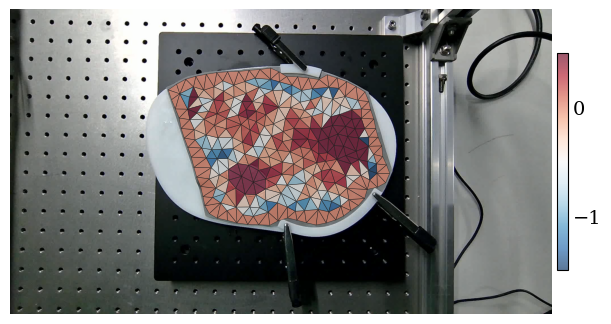

In [7]:
# cmap_custom = sns.color_palette("RdYlBu_r", as_cmap=True)
cmap_custom = sns.color_palette("RdBu_r", as_cmap=True)

# tick_locs = np.arange(np.ceil(np.log10(v_min)), np.floor(np.log10(v_max))+1)
fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
ax1.imshow(bg_0, origin='upper')
im1 = ax1.tripcolor(node_pos_np[:, 0], node_pos_np[:, 1], triangles, 
                    facecolors=zscore_0, shading='flat', 
                    edgecolors='#222222', linewidth=0.4, alpha=0.65, cmap=cmap_custom,    # 
                    vmin=v_min, vmax=v_max)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im1, ax=ax1, pad=0.01, shrink=0.8, aspect=20, fraction=0.02)
cbar1.ax.tick_params(length=0, labelsize=14)
# cbar1.mappable.set_clim(vmin=-, vmax=1)
cbar1.locator = ticker.MultipleLocator(1)
cbar1.update_ticks()

# cbar1.set_ticks(tick_locs)
# cbar1.set_ticklabels([f"$10^{{ {int(loc):d} }}$" for loc in tick_locs])

plt.savefig(f"stiffness_zscore-0.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')

Detected 74 high-probability triangles in init.


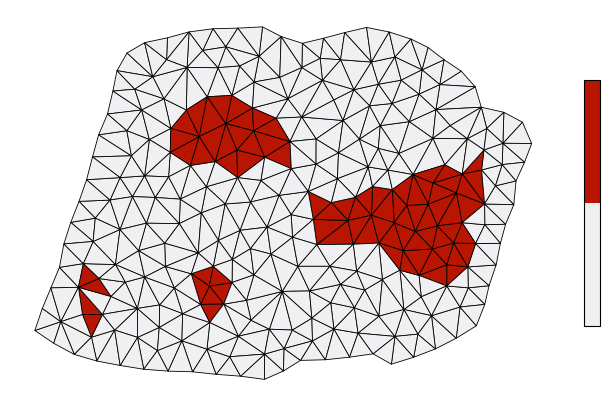

In [8]:
colors = ['#F0F0F2', '#B81502'] # E3F2FD 1F77B4 B81502
cmap_custom = ListedColormap(colors)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im2 = ax1.tripcolor(node_pos_np[:, 0], node_pos_np[:, 1], triangles, 
                    facecolors=high_prob_mask_0.astype(int), shading='flat', 
                    edgecolors='k', linewidth=0.6, cmap=cmap_custom, vmin=0, vmax=1)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im2, ax=ax1, fraction=0.046, shrink=0.5, aspect=15)
cbar1.ax.tick_params(length=0)
cbar1.ax.set_yticklabels([])

plt.savefig(f"target_region_prob_zscore_0.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')
print(f"Detected {high_prob_mask_0.sum()} high-probability triangles in init.")

[Local Evaluation] (Using GT band as reference)
  Band ROC-AUC: 0.9921
  Band PR-AUC: 0.9707
  Local Robust CNR: 1.7491
  Local FDR: 4.7491
[Global Evaluation]
  [Field Metric 1] ROC-AUC: 0.9246 (Closer to 1.0 is better)
  [Field Metric 2] PR-AUC: 0.1642 (Higher is better)
  [Field Metric 3] Robust CNR: 1.5996 (Higher is better)
  [Field Metric 4] FDR: 1.9138 (Higher is better)
[Global Segmentation Evaluation]
  [Seg Metric 1] Dice:       0.2791
  [Seg Metric 2] IoU:        0.1622
  [Seg Metric 3] Precision:  0.1622
  [Seg Metric 4] Recall:     1.0000
  [Seg Metric 5] Specificity:0.8446
  [Seg Metric 6] F1-score:   0.2791

数据来自于sample-3

In [12]:
mesh_1 = np.load("tissue_mesh-1.npz")
node_pos_np_1, triangles_1 = mesh_1['vertices'], mesh_1['faces']
# node_pos_np_1[:, 1] = -node_pos_np_1[:, 1]

In [9]:
zscore_1 = np.loadtxt("zscore_mean-1.csv", delimiter=",")
bg_1 = mpimg.imread("bg-1.png")
high_prob_1 = np.loadtxt("high_value_indices-1.csv", delimiter=",", dtype=int)

high_prob_mask_1 = np.zeros(triangles.shape[0], dtype=bool)
high_prob_mask_1[high_prob_1] = True

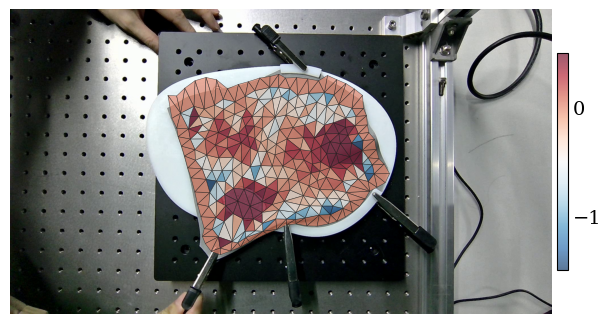

In [13]:
# cmap_custom = sns.color_palette("RdYlBu_r", as_cmap=True)
cmap_custom = sns.color_palette("RdBu_r", as_cmap=True)

# tick_locs = np.arange(np.ceil(np.log10(v_min)), np.floor(np.log10(v_max))+1)
fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
ax1.imshow(bg_1, origin='upper')
im1 = ax1.tripcolor(node_pos_np_1[:, 0], node_pos_np_1[:, 1], triangles_1, 
                    facecolors=zscore_1, shading='flat', 
                    edgecolors='#222222', linewidth=0.4, alpha=0.65, cmap=cmap_custom,    # 
                    vmin=v_min, vmax=v_max)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im1, ax=ax1, pad=0.01, shrink=0.8, aspect=20, fraction=0.02)
cbar1.ax.tick_params(length=0, labelsize=14)
# cbar1.mappable.set_clim(vmin=-, vmax=1)
cbar1.locator = ticker.MultipleLocator(1)
cbar1.update_ticks()

# cbar1.set_ticks(tick_locs)
# cbar1.set_ticklabels([f"$10^{{ {int(loc):d} }}$" for loc in tick_locs])

plt.savefig(f"stiffness_zscore-1.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')

Detected 63 high-probability triangles in init.


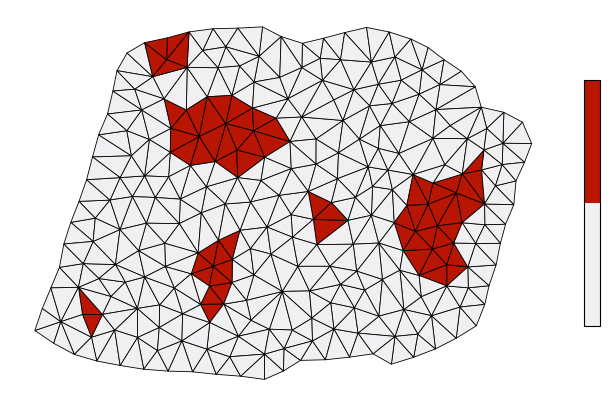

In [ ]:
colors = ['#F0F0F2', '#B81502'] # E3F2FD 1F77B4 B81502
cmap_custom = ListedColormap(colors)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im2 = ax1.tripcolor(node_pos_np[:, 0], node_pos_np[:, 1], triangles, 
                    facecolors=high_prob_mask_1.astype(int), shading='flat', 
                    edgecolors='k', linewidth=0.6, cmap=cmap_custom, vmin=0, vmax=1)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im2, ax=ax1, fraction=0.046, shrink=0.5, aspect=15)
cbar1.ax.tick_params(length=0)
cbar1.ax.set_yticklabels([])

plt.savefig(f"target_region_prob_zscore_1.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')
print(f"Detected {high_prob_mask_1.sum()} high-probability triangles.")

[Local Evaluation] (Using GT band as reference)
  Band ROC-AUC: 1.0000
  Band PR-AUC: 1.0000
  Local Robust CNR: 2.2064
  Local FDR: 8.6810
[Global Evaluation]
  [Field Metric 1] ROC-AUC: 0.9923 (Closer to 1.0 is better)
  [Field Metric 2] PR-AUC: 0.6502 (Higher is better)
  [Field Metric 3] Robust CNR: 2.8327 (Higher is better)
  [Field Metric 4] FDR: 8.5035 (Higher is better)
[Global Segmentation Evaluation]
  [Seg Metric 1] Dice:       0.3200
  [Seg Metric 2] IoU:        0.1905
  [Seg Metric 3] Precision:  0.1905
  [Seg Metric 4] Recall:     1.0000
  [Seg Metric 5] Specificity:0.8722
  [Seg Metric 6] F1-score:   0.3200

数据来自于sample-4

In [19]:
mesh_2 = np.load("tissue_mesh-2.npz")
node_pos_np_2, triangles_2 = mesh_2['vertices'], mesh_2['faces']
# node_pos_np_2[:, 1] = -node_pos_np_2[:, 1]

In [17]:
zscore_2 = np.loadtxt("zscore_mean-2.csv", delimiter=",")
bg_2 = mpimg.imread("bg-2.png")
high_prob_2 = np.loadtxt("high_value_indices-2.csv", delimiter=",", dtype=int)

high_prob_mask_2 = np.zeros(triangles.shape[0], dtype=bool)
high_prob_mask_2[high_prob_2] = True

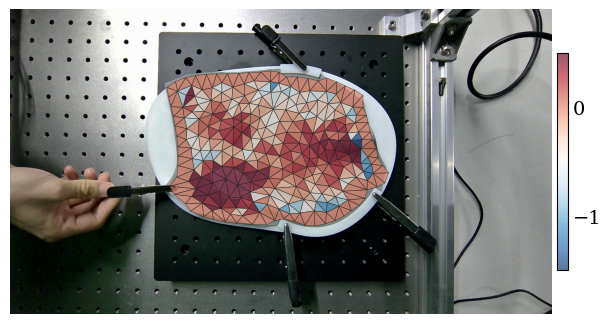

In [20]:
# cmap_custom = sns.color_palette("RdYlBu_r", as_cmap=True)
cmap_custom = sns.color_palette("RdBu_r", as_cmap=True)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
ax1.imshow(bg_2, origin='upper')
im1 = ax1.tripcolor(node_pos_np_2[:, 0], node_pos_np_2[:, 1], triangles_2, 
                    facecolors=zscore_2, shading='flat', 
                    edgecolors='#222222', linewidth=.4, alpha=0.65, cmap=cmap_custom,    # 
                    vmin=v_min, vmax=v_max)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im1, ax=ax1, pad=0.01, shrink=0.8, aspect=20, fraction=0.02)
cbar1.ax.tick_params(length=0, labelsize=14)
# cbar1.mappable.set_clim(vmin=-, vmax=1)
cbar1.locator = ticker.MultipleLocator(1)
cbar1.update_ticks()

# cbar1.set_ticks(tick_locs)
# cbar1.set_ticklabels([f"$10^{{ {int(loc):d} }}$" for loc in tick_locs])

plt.savefig(f"stiffness_inform-zscore-2.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')

Detected 62 high-probability triangles in init.


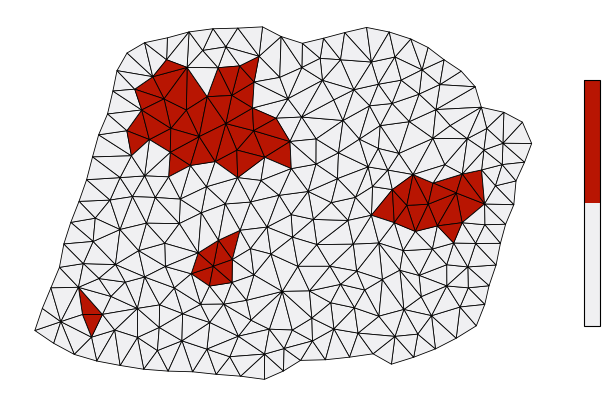

In [ ]:
colors = ['#F0F0F2', '#B81502'] # E3F2FD 1F77B4 B81502
cmap_custom = ListedColormap(colors)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im2 = ax1.tripcolor(node_pos_np[:, 0], node_pos_np[:, 1], triangles, 
                    facecolors=high_prob_mask_2.astype(int), shading='flat', 
                    edgecolors='k', linewidth=0.6, cmap=cmap_custom, vmin=0, vmax=1)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im2, ax=ax1, fraction=0.046, shrink=0.5, aspect=15)
cbar1.ax.tick_params(length=0)
cbar1.ax.set_yticklabels([])

plt.savefig(f"target_region_prob_zscore_2.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')
print(f"Detected {high_prob_mask_2.sum()} high-probability triangles.")

[Local Evaluation] (Using GT band as reference)
  Band ROC-AUC: 1.0000
  Band PR-AUC: 1.0000
  Local Robust CNR: 1.7521
  Local FDR: 8.0649
[Global Evaluation]
  [Field Metric 1] ROC-AUC: 0.9992 (Closer to 1.0 is better)
  [Field Metric 2] PR-AUC: 0.9707 (Higher is better)
  [Field Metric 3] Robust CNR: 3.3951 (Higher is better)
  [Field Metric 4] FDR: 17.1763 (Higher is better)
[Global Segmentation Evaluation]
  [Seg Metric 1] Dice:       0.3243
  [Seg Metric 2] IoU:        0.1935
  [Seg Metric 3] Precision:  0.1935
  [Seg Metric 4] Recall:     1.0000
  [Seg Metric 5] Specificity:0.8747
  [Seg Metric 6] F1-score:   0.3243